# Wohnbevölkerung der Stadt Zürich nach Alter und Postleitzahl

### Kurzbeschreibung
Wohnbevölkerung der Stadt Zürich nach Alter (5-Jahres-Altersklassen) und Postleitzahl. Es kann Postleitzahlen geben, die sowohl auf dem Gebiet der Stadt Zürich und auch ausserhalb umfassen. Im vorliegenden Datensatz ist aber nur die Wohnbevölkerung der Stadt Zürich vorhanden.

Datum: 25.06.2024


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_alter_plz_od5270

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_alter_plz_od5270


### Importiere die notwendigen Packages

In [ ]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [1]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [2]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [3]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [4]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [5]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [6]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [7]:
package_name = "bev_bestand_jahr_alter_plz_od5270"

In [38]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV527OD5270"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_alter_plz_od5270/download/BEV527OD5270.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_alter_plz_od5270 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_alter_plz_od5270 

data_source: web


In [39]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1993-01-01 00:00:00,1993-01-01 00:00:00
AlterV05Sort,1,1
AlterV05Cd,0,0
AlterV05Lang,0- bis 4-Jährige,0- bis 4-Jährige
PLZ,8001,8002
AnzBestWir,137,364


Berechne weitere Attribute falls notwendig

In [40]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
AlterV05Sort                    int64
AlterV05Cd                      int64
AlterV05Lang                   object
PLZ                             int64
AnzBestWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [41]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2024


### Einfache Datentests

In [42]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 17327 entries, 17326 to 0
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      17327 non-null  datetime64[ns]
 1   AlterV05Sort         17327 non-null  int64         
 2   AlterV05Cd           17327 non-null  int64         
 3   AlterV05Lang         17327 non-null  object        
 4   PLZ                  17327 non-null  int64         
 5   AnzBestWir           17327 non-null  int64         
 6   StichtagDatJahr_str  17327 non-null  object        
 7   Jahr                 17327 non-null  datetime64[ns]
 8   Jahr_end             17327 non-null  datetime64[ns]
 9   Jahr_nbr             17327 non-null  int32         
dtypes: datetime64[ns](3), int32(1), int64(4), object(2)
memory usage: 3.9 MB


In [43]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 17,327 rows (observations) and 10 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [44]:
data2betested.describe()

,StichtagDatJahr,AlterV05Sort,AlterV05Cd,PLZ,AnzBestWir,Jahr,Jahr_end,Jahr_nbr
count,17327,17327,17327,17327,17327,17327,17327,17327
mean,2008-05-03 13:04:26.982166528,11,49,8076,722,2008-05-03 13:04:26.982166528,2009-05-02 19:02:43.513591808,2008
min,1993-01-01 00:00:00,1,0,8001,1,1993-01-01 00:00:00,1993-12-31 00:00:00,1993
25%,2000-01-01 00:00:00,6,25,8008,215,2000-01-01 00:00:00,2000-12-31 00:00:00,2000
50%,2008-01-01 00:00:00,11,50,8045,589,2008-01-01 00:00:00,2008-12-31 00:00:00,2008
75%,2016-01-01 00:00:00,16,75,8052,1042,2016-01-01 00:00:00,2016-12-31 00:00:00,2016
max,2024-01-01 00:00:00,21,100,9999,4502,2024-01-01 00:00:00,2024-12-31 00:00:00,2024
std,NaN,6,30,269,658,NaN,NaN,9


Welches sind die Quartiere ohne Werte bei BEW?

In [45]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,AlterV05Sort,AlterV05Cd,AlterV05Lang,PLZ,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [46]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [47]:
data2betested.index.year.unique()

Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [48]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [49]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,AlterV05Sort,AlterV05Cd,PLZ,AnzBestWir,Jahr_nbr
count,"17,327","17,327","17,327","17,327","17,327"
mean,11,49,"8,076",722,"2,008"
std,6,30,269,658,9
min,1,0,"8,001",1,"1,993"
25%,6,25,"8,008",215,"2,000"
50%,11,50,"8,045",589,"2,008"
75%,16,75,"8,052","1,042","2,016"
max,21,100,"9,999","4,502","2,024"


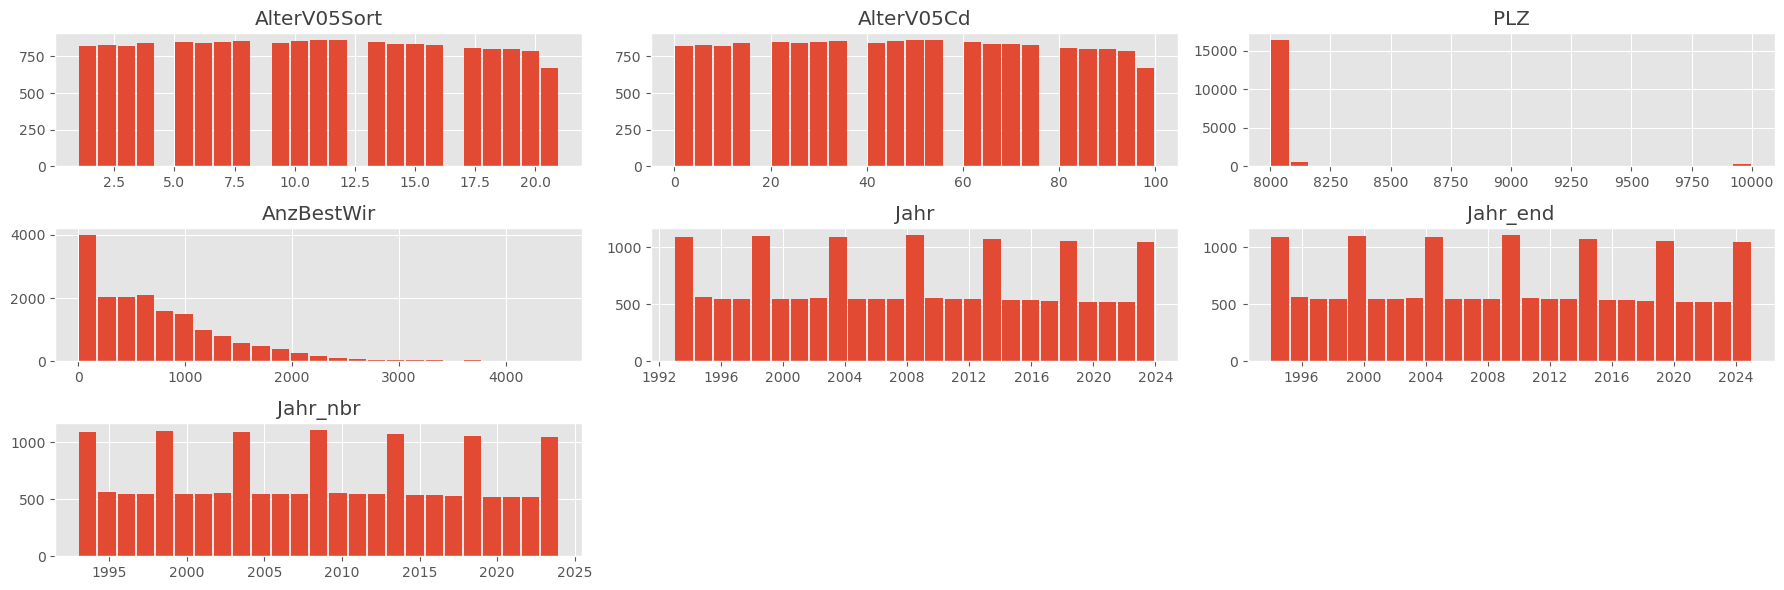

In [50]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [51]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,AlterV05Sort,AlterV05Cd,AlterV05Lang,PLZ,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,,


### Nullwerte und Missings?

In [52]:
data2betested.isnull().sum()

AlterV05Sort           0
AlterV05Cd             0
AlterV05Lang           0
PLZ                    0
AnzBestWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_end               0
Jahr_nbr               0
dtype: int64

In [53]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [54]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,sum_AnzBestWir
0,2024-01-01,2024,2024-12-31,448664
1,2023-01-01,2023,2023-12-31,447082
2,2022-01-01,2022,2022-12-31,443037


In [55]:
agg_alter= data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterV05Cd', 'AlterV05Lang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AlterV05Cd', ascending=False) 
agg_alter.reset_index().head(3)

,AlterV05Cd,AlterV05Lang,sum_AnzBestWir
0,100,100-Jährige und Ältere,2580
1,95,95- bis 99-Jährige,23356
2,90,90- bis 94-Jährige,96319


In [56]:
agg_plz= data2betested.loc[data_min_date:data_max_date]\
    .groupby(['PLZ',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('sum_AnzBestWir', ascending=False) 
agg_plz.reset_index().head(3)

,PLZ,sum_AnzBestWir
0,8004,876176
1,8048,857341
2,8050,824853


### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [57]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,AlterV05Sort,AlterV05Cd,AlterV05Lang,PLZ,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,,
2024-01-01,1,0,0- bis 4-Jährige,8008,784,2024-01-01,2024-01-01,2024-12-31,2024
2024-01-01,1,0,0- bis 4-Jährige,8037,766,2024-01-01,2024-01-01,2024-12-31,2024


----------------------------------------------------------------------------------------
**Selektionen und Aggregationen**

Check this [Doku](https://www.shanelynn.ie/summarising-aggregation-and-grouping-data-in-python-pandas/)

### Visualisierungen nach Zeitausschnitten

In [58]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'AlterV05Sort', 'AlterV05Cd', 'AlterV05Lang', 'PLZ', 'AnzBestWir',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

#### Entwicklung Wochenaufenthaltender nach Altersgruppe

In [59]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'AlterV05Cd', 'AlterV05Lang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,AlterV05Cd,AlterV05Lang,sum_WBev
0,1993-01-01,0,0- bis 4-Jährige,15637
1,1993-01-01,100,100-Jährige und Ältere,30
2,1993-01-01,95,95- bis 99-Jährige,381


In [60]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('AlterV05Cd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "AlterV05Lang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Wohnbevölkerung nach Altersgruppe, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung nach PLZ

In [61]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'PLZ']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg2.reset_index().head(3)

,StichtagDatJahr,PLZ,sum_WBev
0,1993-01-01,8001,5589
1,1993-01-01,9999,137
2,1993-01-01,8152,11


In [62]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('PLZ', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "PLZ:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Wohnbevölkerung nach Postleitzahl, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

##### Kombinierte Grafik in Altair

In [63]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik2)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik2, spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#999980",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

#### Faced Grids

In [70]:
myFG = data2betested\
    .groupby(['StichtagDatJahr', 'PLZ', 'AlterV05Cd', 'AlterV05Lang', 'Jahr_nbr']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('PLZ', ascending=True) 
myFG.head(2)

,,,,,sum_WBev
StichtagDatJahr,PLZ,AlterV05Cd,AlterV05Lang,Jahr_nbr,
1993-01-01,8001,0,0- bis 4-Jährige,1993,137
2012-01-01,8001,55,55- bis 59-Jährige,2012,308


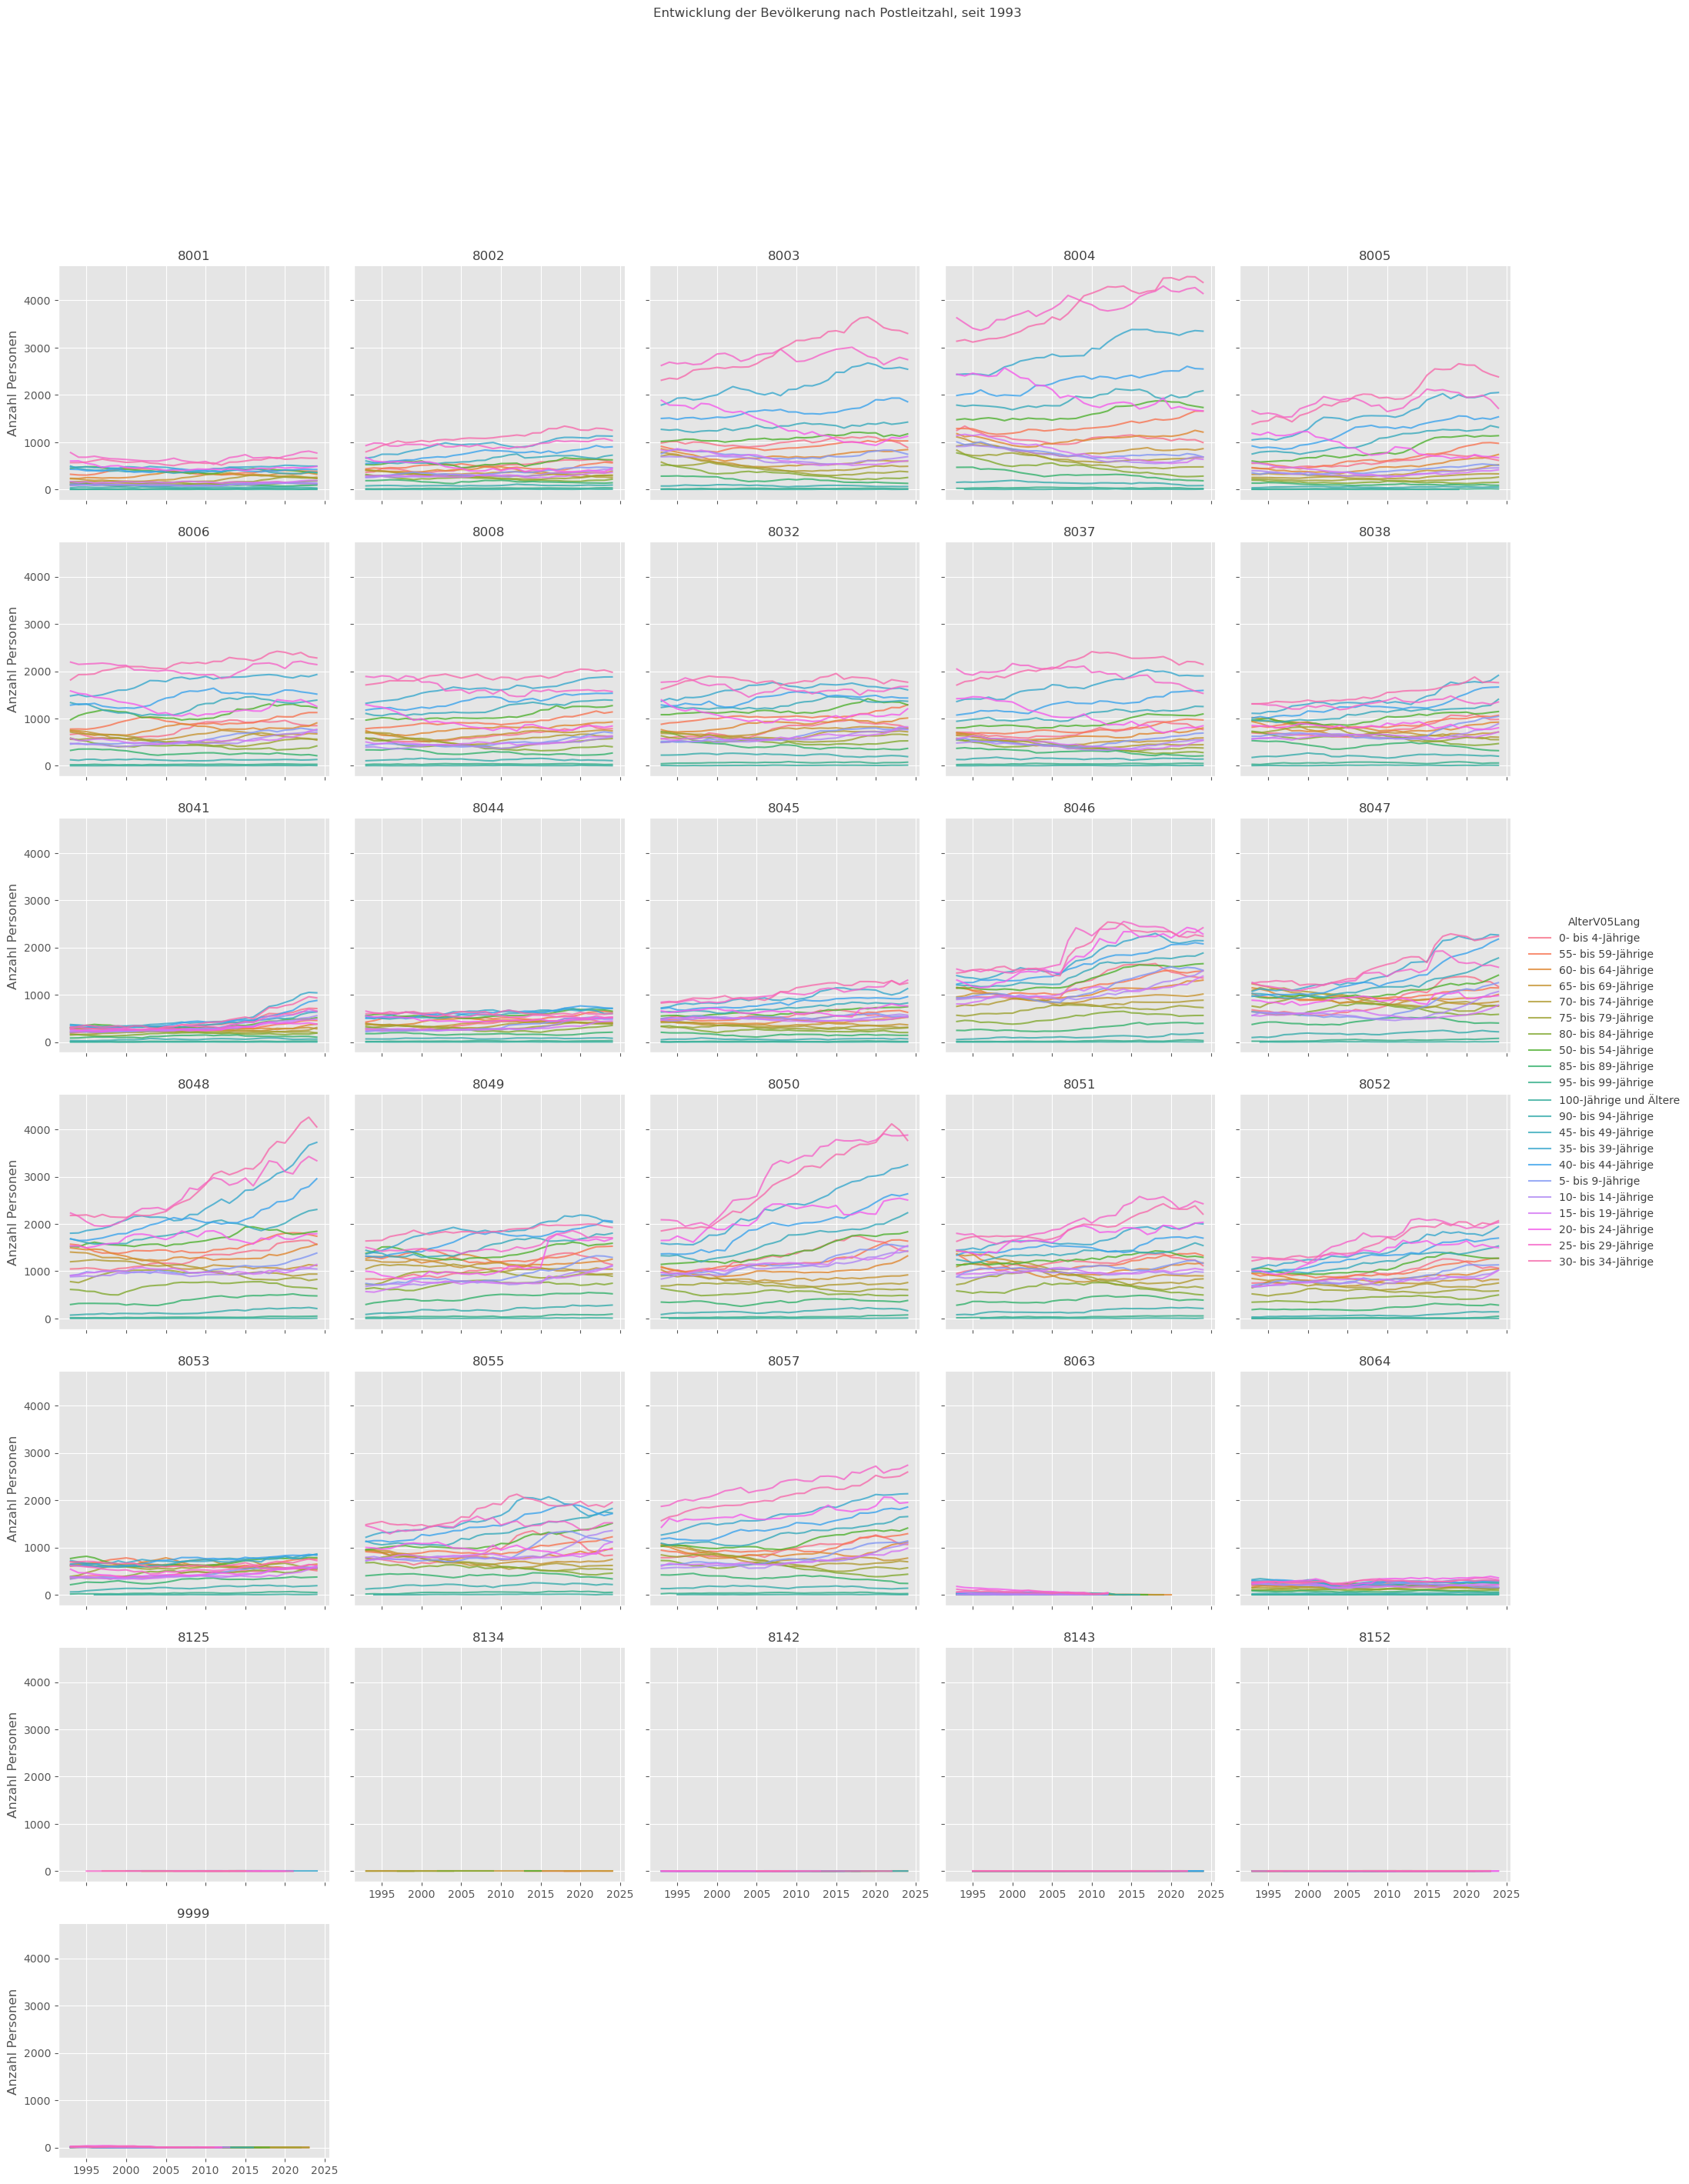

In [73]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index()
    , col = "PLZ"
    , hue = "AlterV05Lang"
    , col_wrap = 5
    , height = 3
    , grafiktyp = sns.lineplot
    , x = "Jahr_nbr"
    , y = "sum_WBev"
    , ylabel= "Anzahl Personen"
    , myTitle="Entwicklung der Bevölkerung nach Postleitzahl, seit "+str(data2betested.index.year.min())
    )

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [74]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [ ]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['AlterV05Lang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', '0- bis 4-Jährige': '#A30059', '5- bis 9-Jährige': '#DB247D', '50- bis 54-Jährige': '#FF579E', '10- bis 14-Jährige': '#FFA8D0', '25- bis 29-Jährige': '#E4E0DF', '15- bis 19-Jährige': '#A8DBB1', '20- bis 24-Jährige': '#55BC5D', '40- bis 44-Jährige': '#1F9E31', '30- bis 34-Jährige': '#10652A', '35- bis 39-Jährige': '#0017BF', '45- bis 49-Jährige': '#0072D7', '65- bis 69-Jährige': '#00A5D2', '60- bis 64-Jährige': '#5E359A', '55- bis 59-Jährige': '#BA0062', '75- bis 79-Jährige': '#DA5563', '70- bis 74-Jährige': '#00615D', '95- bis 99-Jährige': '#00770F', '80- bis 84-Jährige': '#7BA600', '85- bis 89-Jährige': '#7B4100', '90- bis 94-Jährige': '#DC5500', '100-Jährige und Ältere': '#DA9C00'}


In [ ]:
data2betested.columns

Index(['AlterV05Sort', 'AlterV05Cd', 'AlterV05Lang', 'PLZ', 'AnzBestWir', 'StichtagDatJahr_str',
       'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

##### Wohnbevölkerung nach PLZ und ALtersgruppe

In [ ]:
data2betested.columns

Index(['AlterV05Sort', 'AlterV05Cd', 'AlterV05Lang', 'PLZ', 'AnzBestWir', 'StichtagDatJahr_str',
       'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [ ]:
myTM = data2betested.loc[data_max_date].reset_index() \
    .groupby(['StichtagDatJahr', 'AlterV05Cd', 'AlterV05Lang', 'PLZ',]) \
    .agg(AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AnzBestWir', ascending=False) 

myTM.reset_index().head(2)

,StichtagDatJahr,AlterV05Cd,AlterV05Lang,PLZ,AnzBestWir
0,2024-01-01,30,30- bis 34-Jährige,8004,4380
1,2024-01-01,25,25- bis 29-Jährige,8004,4146


In [ ]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['AlterV05Lang','PLZ']
    ,values="AnzBestWir"
    ,color="AnzBestWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Wohnen':'lightblue'}   
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Wochenaufenthaltende nach Zuzugsgebiet, "+data_max_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000026957601290>, 'AlterV05Lang', 'PLZ']
Typ von path: <class 'list'>


##### Wohnbevölkerung nach Altersgruppe und PLZ

In [ ]:
myTM2 = data2betested.loc[data_max_date].reset_index() \
    .groupby(['StichtagDatJahr', 'AlterV05Lang','PLZ']) \
    .agg(AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AnzBestWir', ascending=False) 
myTM2.reset_index().head(2)

,StichtagDatJahr,AlterV05Lang,PLZ,AnzBestWir
0,2024-01-01,30- bis 34-Jährige,8004,4380
1,2024-01-01,25- bis 29-Jährige,8004,4146


In [ ]:
#agg_age
#agg_age.reset_index().dtypes

In [82]:
treeMap2= mypy_dv.plot_px_treemap(
    data=myTM2.reset_index()
    ,levels=['AlterV05Lang','PLZ']
    ,values="AnzBestWir"
    ,color="AlterV05Lang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Wochenaufenthaltende nach Altersgruppe und Zuzugsgebiet, "+data_max_date
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x000002695751ED50>, 'AlterV05Lang', 'PLZ']
Typ von path: <class 'list'>


In [83]:
treeMap3= mypy_dv.plot_px_treemap(
    data=myTM2.reset_index()
    ,levels=['PLZ','AlterV05Lang',]
    ,values="AnzBestWir"
    ,color="AlterV05Lang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Wochenaufenthaltende nach Altersgruppe und Zuzugsgebiet, "+data_max_date
)
treeMap3

path: [<plotly.express._special_inputs.Constant object at 0x00000269570F07D0>, 'PLZ', 'AlterV05Lang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=920&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FAllItems%2Easpx%23InplviewHasha5c3e41f%2D51c0%2D4959%2D84f9%2D641e43e48747%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------